<a id="setup"></a>
## 1. Setup & Dependencies

# Speech Emotion Recognition using Random Forest



In [1]:
# Import required libraries
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import time

In [2]:
# Load training data and labels
train_X = np.load("training_data_projectC.npy").T
train_t = np.load("training_labels_projectC.npy")

### 1.1 Load Training Data

In [3]:
# Check data dimensions
print(f"Audio data shape: {train_X.shape}")
print(f"Labels shape: {train_t.shape}")
print(f"Number of samples: {train_X.shape[0]}")
print(f"Audio length per sample: {train_X.shape[1]} samples")
train_X.shape, train_t.shape

Audio data shape: (900, 144000)
Labels shape: (900,)
Number of samples: 900
Audio length per sample: 144000 samples


((900, 144000), (900,))

In [4]:
sr = 48000  # Sample rate
N_fft = 1024  # FFT window size
HOP_len = 512  # Hop length: number of samples between the starts of two consecutive windows
N_melband = 128  # Number of mel bands
f_max = 8000  # Maximum frequency (Hz)

<a id="features"></a>
## 2. Feature Extraction

### 2.1 Audio Processing Parameters

In [5]:
# Extract mel-spectrogram features from raw audio
melspec = librosa.feature.melspectrogram(
    y=train_X,
    sr=sr,
    n_fft=N_fft,
    hop_length=HOP_len,
    n_mels=N_melband,
    fmax=f_max,
)
print(f"Mel-spectrogram shape: {melspec.shape}")

Mel-spectrogram shape: (900, 128, 282)


### 2.2 Extract Mel-Spectrogram Features

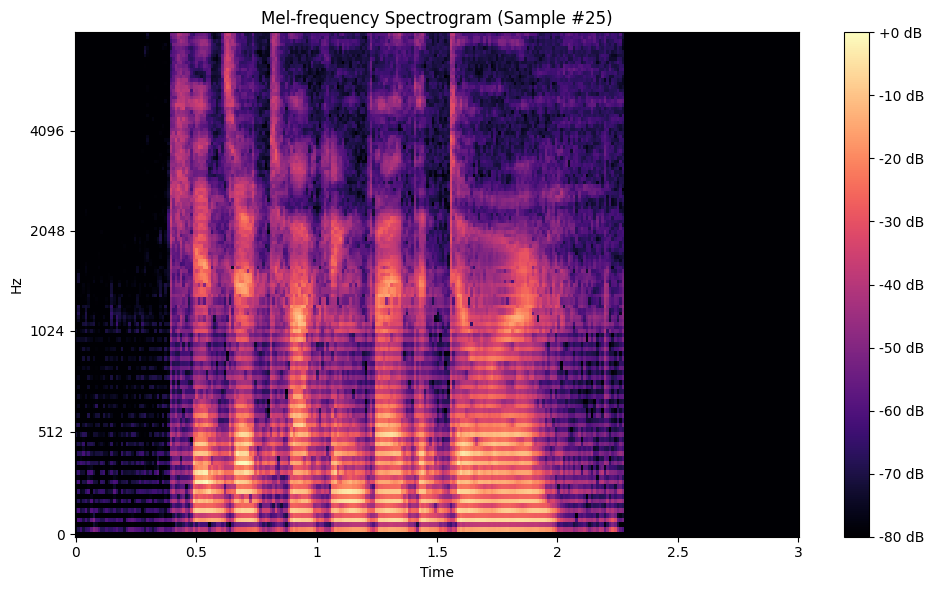

In [6]:
# Visualize mel-spectrogram (sample #25)
fig, ax = plt.subplots(figsize=(10, 6))
melspec_dB = librosa.power_to_db(melspec[25], ref=np.max)
img = librosa.display.specshow(
    melspec_dB, x_axis='time',
    y_axis='mel', sr=sr,
    fmax=f_max, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency Spectrogram (Sample #25)')
plt.tight_layout()

### 2.3 Visualize Mel-Spectrogram

In [7]:
# Build basic feature matrix with statistical measures
# Extract mean, std, max, min across time axis for each mel band
# Result: 900 samples × (128 bands × 4 statistics) = 900×512 matrix
feature_matrix = np.hstack((
    np.mean(melspec, axis=2), 
    np.std(melspec, axis=2), 
    np.max(melspec, axis=2), 
    np.min(melspec, axis=2)
))
print(f"Basic feature matrix shape: {feature_matrix.shape}")

Basic feature matrix shape: (900, 512)


### 2.4 Build Basic Feature Matrix

In [8]:
# Split data into train/test sets using stratified split
# test_size=0.2 means 20% for testing, 80% for training
# stratify ensures each class is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, 
    train_t, 
    test_size=0.2, 
    stratify=train_t,
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  Class {int(label)}: {count} samples ({count/len(y_train)*100:.1f}%)")
print(f"\nTest set class distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  Class {int(label)}: {count} samples ({count/len(y_test)*100:.1f}%)")

Training set size: 720 samples
Test set size: 180 samples

Training set class distribution:
  Class 1: 145 samples (20.1%)
  Class 2: 144 samples (20.0%)
  Class 3: 145 samples (20.1%)
  Class 4: 140 samples (19.4%)
  Class 5: 146 samples (20.3%)

Test set class distribution:
  Class 1: 37 samples (20.6%)
  Class 2: 36 samples (20.0%)
  Class 3: 36 samples (20.0%)
  Class 4: 35 samples (19.4%)
  Class 5: 36 samples (20.0%)


<a id="baseline"></a>
## 3. Baseline Random Forest Model

### 3.1 Train/Test Split

In [9]:
# Baseline Random Forest model (with pre-tuned hyperparameters)
RFC = RandomForestClassifier(
    n_estimators=160, 
    criterion='entropy', 
    bootstrap=False, 
    max_features='log2', 
    random_state=8128
)
RFC.fit(X_train, y_train)

# Evaluate on both training and test sets
train_accuracy = RFC.score(X_train, y_train)
test_accuracy = RFC.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Training accuracy: 1.0000 (100.00%)
Test accuracy: 0.7111 (71.11%)


### 3.2 Train Baseline Model

In [10]:
# Perform 10-fold stratified cross-validation on baseline model
stratified_k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=496)
cv_scores = cross_val_score(RFC, X_train, y_train, cv=stratified_k_fold, scoring='accuracy')


print(f"CV scores per fold: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"Standard deviation: {cv_scores.std():.4f}")
print(f"Accuracy range: {cv_scores.min():.4f} - {cv_scores.max():.4f}")

CV scores per fold: [0.70833333 0.79166667 0.59722222 0.69444444 0.76388889 0.72222222
 0.81944444 0.73611111 0.66666667 0.72222222]
Mean CV accuracy: 0.7222 (72.22%)
Standard deviation: 0.0599
Accuracy range: 0.5972 - 0.8194


### 3.3 Cross-Validation

In [11]:
# Original features
feature_mean = np.mean(melspec, axis=2)
feature_std = np.std(melspec, axis=2)
feature_max = np.max(melspec, axis=2)
feature_min = np.min(melspec, axis=2)

# Additional features
feature_median = np.median(melspec, axis=2)  # Median
feature_q25 = np.percentile(melspec, 25, axis=2)  # 25th percentile
feature_q75 = np.percentile(melspec, 75, axis=2)  # 75th percentile
# Skewness: measure of asymmetry in distribution
feature_skew = np.array([
    np.apply_along_axis(
        lambda x: np.mean((x - np.mean(x))**3) / (np.std(x)**3 + 1e-10), 
        1, melspec[i]
    ) for i in range(melspec.shape[0])
])

# Combine all features
feature_matrix_enhanced = np.hstack((
    feature_mean, 
    feature_std, 
    feature_max, 
    feature_min,
    feature_median,
    feature_q25,
    feature_q75,
    feature_skew
))

print(f"Basic feature matrix size: (900, 512)")
print(f"Enhanced feature matrix size: {feature_matrix_enhanced.shape}")
print(f"Feature increase: {feature_matrix_enhanced.shape[1] / 512:.1f}x")

Basic feature matrix size: (900, 512)
Enhanced feature matrix size: (900, 1024)
Feature increase: 2.0x


<a id="enhanced"></a>
## 4. Feature Enhancement & Model Optimization

In [12]:
### Step 2: Feature Standardization

# Split enhanced features into train/test
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    feature_matrix_enhanced, 
    train_t, 
    test_size=0.2, 
    stratify=train_t,
    random_state=42
)

# Standardize features (fit on training set only, then transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enh)
X_test_scaled = scaler.transform(X_test_enh)


print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Training set size: (720, 1024)
Test set size: (180, 1024)


In [13]:
### Step 3: Train Random Forest with Enhanced Features

RFC_enhanced = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy', 
    bootstrap=False, 
    max_features='sqrt',
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=8128
)

RFC_enhanced.fit(X_train_scaled, y_train_enh)

# Evaluate performance
train_acc_enh = RFC_enhanced.score(X_train_scaled, y_train_enh)
test_acc_enh = RFC_enhanced.score(X_test_scaled, y_test_enh)


print(f"Training accuracy: {train_acc_enh:.4f} ({train_acc_enh*100:.2f}%)")
print(f"Test accuracy: {test_acc_enh:.4f} ({test_acc_enh*100:.2f}%)")
print(f"Improvement over baseline: {(test_acc_enh - test_accuracy)*100:+.2f}%")

Training accuracy: 1.0000 (100.00%)
Test accuracy: 0.7556 (75.56%)
Improvement over baseline: +4.44%


In [14]:
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [25, 30, 35, None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

RFC_grid = RandomForestClassifier(
    criterion='entropy',
    bootstrap=False,
    random_state=8128
)

grid_search = GridSearchCV(
    RFC_grid, 
    param_grid, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=496),
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 
)


grid_search.fit(X_train_scaled, y_train_enh)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

best_test_acc = grid_search.best_estimator_.score(X_test_scaled, y_test_enh)
print(f"Test set accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best parameters: {'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
Best CV accuracy: 0.7556 (75.56%)
Test set accuracy: 0.7778 (77.78%)


<a id="tuning"></a>
## 5. Hyperparameter Tuning

In [15]:
gbc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=8128,
    verbose=0
)
gbc.fit(X_train_scaled, y_train_enh)
gbc_test_acc = gbc.score(X_test_scaled, y_test_enh)
print(f"Gradient Boosting test accuracy: {gbc_test_acc:.4f} ({gbc_test_acc*100:.2f}%)")

# Support Vector Machine with RBF kernel
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=8128)
svm.fit(X_train_scaled, y_train_enh)
svm_test_acc = svm.score(X_test_scaled, y_test_enh)
print(f"SVM test accuracy: {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")

Gradient Boosting test accuracy: 0.7056 (70.56%)
SVM test accuracy: 0.6222 (62.22%)


<a id="comparison"></a>
## 6. Model Comparison & Ensemble Methods

In [ ]:


# Create Voting Classifier (combines predictions from multiple models)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RFC_enhanced),
        ('gbc', gbc),
        ('svm', svm)
    ],
    voting='hard'  # Use majority voting
)

voting_clf.fit(X_train_scaled, y_train_enh)
voting_test_acc = voting_clf.score(X_test_scaled, y_test_enh)


print(f"Random Forest (enhanced):  {test_acc_enh:.4f} ({test_acc_enh*100:.2f}%)")
print(f"Gradient Boosting:         {gbc_test_acc:.4f} ({gbc_test_acc*100:.2f}%)")
print(f"SVM:                       {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")
print(f"Voting Classifier:         {voting_test_acc:.4f} ({voting_test_acc*100:.2f}%)")
print(f"\nBest test accuracy: {max(test_acc_enh, gbc_test_acc, svm_test_acc, voting_test_acc):.4f}")


Training Voting Classifier (ensemble of 3 models)...
Random Forest (enhanced):  0.7556 (75.56%)
Gradient Boosting:         0.7056 (70.56%)
SVM:                       0.6222 (62.22%)
Voting Classifier:         0.7500 (75.00%)

Best test accuracy: 0.7556
